In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
file_path = '/content/drive/MyDrive/FYP/Datasets/machine_learning_balance_CIC-IDS-2017_data.csv'
df = pd.read_csv(file_path)
print(df)

         flow_duration  total_fwd_packets  total_backward_packets  \
0               1001.0                4.0                     0.0   
1          101613739.0                8.0                     5.0   
2             285697.0                2.0                     2.0   
3                196.0                2.0                     2.0   
4              60643.0                1.0                     1.0   
...                ...                ...                     ...   
1113387      1216777.0               19.0                    20.0   
1113388    115728534.0               20.0                    17.0   
1113389          231.0                2.0                     2.0   
1113390      1785987.0                5.0                     0.0   
1113391        84484.0                2.0                     2.0   

          flow_bytes/s  flow_packets/s  packet_length_mean  packet_length_std  \
0             0.000000     3996.003996            0.000000           0.000000   
1        

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
X = df.drop('label', axis=1)
y = df['label']

# Handle NaN and infinite values
X = X.replace([float('inf'), -float('inf')], pd.NA)
X = X.fillna(0)

<ipython-input-6-451c76383a95>:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(0)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9859

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99    111397
           1       0.98      0.99      0.99    111282

    accuracy                           0.99    222679
   macro avg       0.99      0.99      0.99    222679
weighted avg       0.99      0.99      0.99    222679


Confusion Matrix:
 [[109619   1778]
 [  1358 109924]]


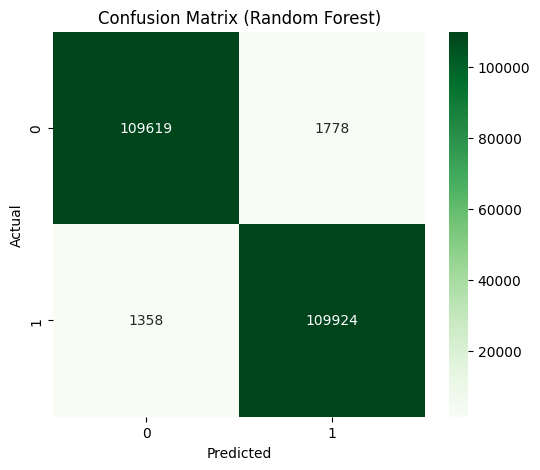

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest)')
plt.show()


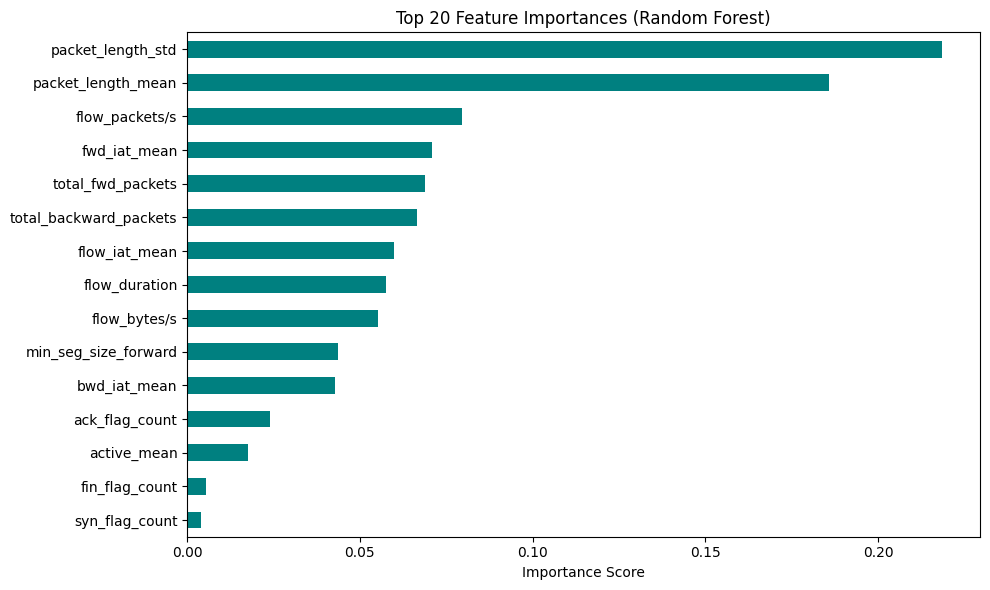

In [ ]:
import pandas as pd

importances = rf_model.feature_importances_
feature_names = X.columns

# Create a series for plotting
feat_imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
feat_imp_series.plot(kind='barh', color='teal')
plt.xlabel("Importance Score")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
